In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 19:31:37.866 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:38.232 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:38.234 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:38.238 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


/tmp/ipykernel_18594/2311668351.py:237: UserWarning: Unnamed cells, 2 in 'diff_pair_cmirrorbias'
  comp.write_gds("diff_pair_cmirrorbias.gds")
2026-05-18 19:31:49.761 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'diff_pair_cmirrorbias.gds'


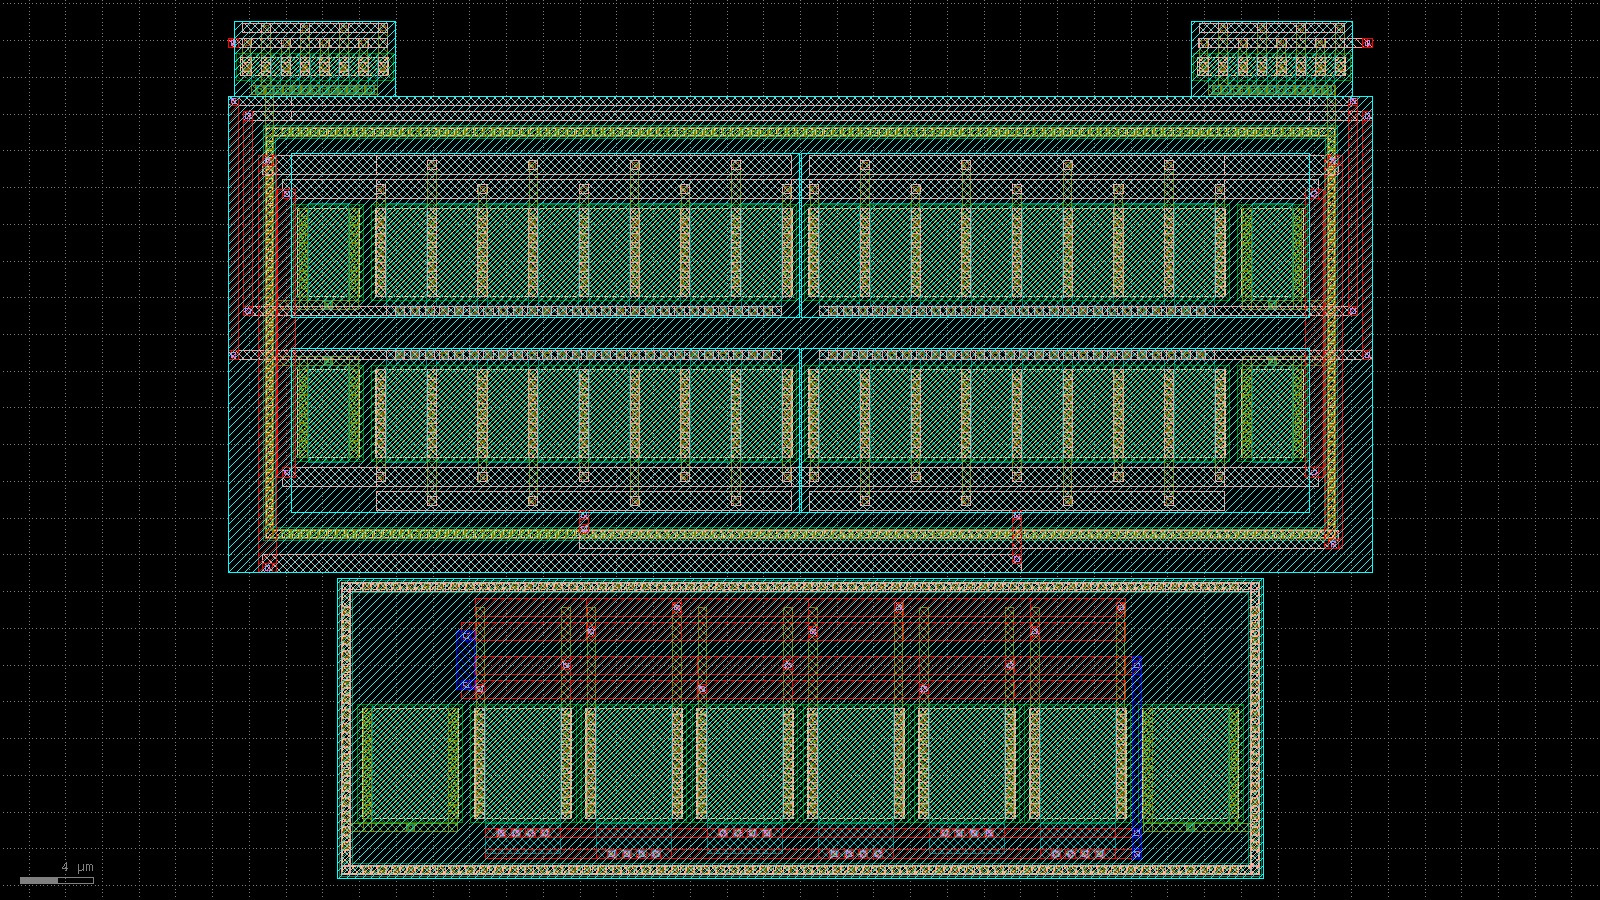

/home/irman/Gelochip/src/gelochip/glayout/pdk/mappedpdk.py:538: UserWarning: Unnamed cells, 2 in 'diff_pair_cmirrorbias'
  layout.write_gds(gds_path)
2026-05-18 19:31:49.901 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp4wq3kzrg/diff_pair_cmirrorbias.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


/home/irman/Gelochip/src/gelochip/glayout/pdk/mappedpdk.py:762: UserWarning: Unnamed cells, 2 in 'diff_pair_cmirrorbias'
  layout.write_gds(str(gds_path))
2026-05-18 19:31:50.305 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpy4kh3cfe/diff_pair_cmirrorbias.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmp4wq3kzrg/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "diff_pair_cmirrorbias".
Reading


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "diff_pair_cmirrorbias".
Reading "c_rout

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from gdsfactory.cell import cell, clear_cache
from gdsfactory.component import Component, copy
from gdsfactory.component_reference import ComponentReference
from gdsfactory.components.rectangle import rectangle
from glayout import MappedPDK
from glayout.routing import c_route,L_route,straight_route
from typing import Optional, Union
from glayout.cells.elementary.diff_pair import diff_pair
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.primitives.guardring import tapring
from glayout.primitives.mimcap import mimcap_array, mimcap
from glayout.primitives.via_gen import via_stack, via_array
from gdsfactory.routing.route_quad import route_quad
from glayout.util.comp_utils import (
    evaluate_bbox,
    prec_ref_center,
    movex,
    movey,
    to_decimal,
    to_float,
    move,
    align_comp_to_port,
    get_padding_points_cc,
)
from glayout.util.port_utils import (
    rename_ports_by_orientation,
    rename_ports_by_list,
    add_ports_perimeter,
    print_ports,
    set_port_orientation,
    rename_component_ports,
)
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.placement.two_transistor_interdigitized import two_nfet_interdigitized
from glayout.spice import Netlist
from glayout.cells.elementary.current_mirror import current_mirror_netlist

def diff_pair_ibias_netlist(center_diffpair: Component, current_mirror: Component, antenna_diode: Optional[Component] = None) -> Netlist:
    netlist = Netlist(
        circuit_name="DIFFPAIR_CMIRROR_BIAS",
        nodes=['VP', 'VN', 'VDD1', 'VDD2', 'IBIAS', 'VSS', 'B']
    )

    diffpair_ref = netlist.connect_netlist(
        center_diffpair.info['netlist'],
        []
    )

    cmirror_ref = netlist.connect_netlist(
        current_mirror.info['netlist'],
        [('VREF', 'IBIAS'), ('B', 'VSS')]
    )

    netlist.connect_subnets(
        cmirror_ref,
        diffpair_ref,
        [('VOUT', 'VTAIL')]
    )

    if antenna_diode is not None:
        netlist.connect_netlist(
            antenna_diode.info['netlist'],
            [('D', 'VSS'), ('G', 'VSS'), ('B', 'VSS'), ('S', 'VP')]
        )

        netlist.connect_netlist(
            antenna_diode.info['netlist'],
            [('D', 'VSS'), ('G', 'VSS'), ('B', 'VSS'), ('S', 'VN')]
        )

    return netlist

def diff_pair_ibias(
    pdk: MappedPDK,
    half_diffpair_params: tuple[float, float, int],
    diffpair_bias: tuple[float, float, int],
    rmult: int,
    with_antenna_diode_on_diffinputs: int,
) -> Component:
    # create and center diffpair
    diffpair_i_ = Component("temp diffpair and current source")
    center_diffpair_comp = diff_pair(
        pdk,
        width=half_diffpair_params[0],
        length=half_diffpair_params[1],
        fingers=half_diffpair_params[2],
        rmult=rmult,
    )
    # add antenna diodes if that option was specified
    diffpair_centered_ref = prec_ref_center(center_diffpair_comp)
    diffpair_i_.add(diffpair_centered_ref)
    diffpair_i_.add_ports(diffpair_centered_ref.get_ports_list())
    antenna_diode_comp = None
    if with_antenna_diode_on_diffinputs:
        antenna_diode_comp = nmos(
            pdk,
            1,
            with_antenna_diode_on_diffinputs,
            1,
            with_dummy=False,
            with_tie=False,
            with_substrate_tap=False,
            with_dnwell=False,
            length=0.5,
            sd_route_topmet="met2",
            gate_route_topmet="met1",
        ).copy()
        antenna_diode_comp << straight_route(
            pdk,
            antenna_diode_comp.ports["multiplier_0_row0_col0_rightsd_top_met_S"],
            antenna_diode_comp.ports["multiplier_0_gate_N"],
        )
        antenna_diode_refL = diffpair_i_ << antenna_diode_comp
        antenna_diode_refR = diffpair_i_ << antenna_diode_comp
        align_comp_to_port(
            antenna_diode_refL, diffpair_i_.ports["MINUSgateroute_W_con_N"], ("r", "t")
        )
        antenna_diode_refL.movex(pdk.util_max_metal_seperation())
        align_comp_to_port(
            antenna_diode_refR, diffpair_i_.ports["MINUSgateroute_E_con_N"], ("L", "t")
        )
        antenna_diode_refR.movex(0 - pdk.util_max_metal_seperation())
        # route the antenna diodes to gnd and
        Lgndcon = diffpair_i_.ports["tap_W_top_met_N"]
        Lgndcon.layer = pdk.get_glayer("met1")
        Rgndcon = diffpair_i_.ports["tap_E_top_met_N"]
        Rgndcon.layer = pdk.get_glayer("met1")
        diffpair_i_ << L_route(
            pdk, antenna_diode_refL.ports["multiplier_0_gate_E"], Lgndcon
        )
        diffpair_i_ << L_route(
            pdk, antenna_diode_refR.ports["multiplier_0_gate_W"], Rgndcon
        )
        diffpair_i_ << straight_route(
            pdk,
            antenna_diode_refL.ports["multiplier_0_source_W"],
            diffpair_i_.ports["MINUSgateroute_W_con_N"],
        )
        diffpair_i_ << straight_route(
            pdk,
            antenna_diode_refR.ports["multiplier_0_source_W"],
            diffpair_i_.ports["PLUSgateroute_E_con_N"],
        )
    # create and position tail current source
    cmirror = two_nfet_interdigitized(
        pdk,
        width=diffpair_bias[0],
        length=diffpair_bias[1],
        numcols=diffpair_bias[2],
        with_tie=True,
        with_substrate_tap=False,
        gate_route_topmet="met3",
        sd_route_topmet="met3",
        rmult=rmult,
        tie_layers=("met2", "met2"),
    )
    # cmirror routing
    metal_sep = pdk.util_max_metal_seperation()
    gate_short = cmirror << c_route(
        pdk,
        cmirror.ports["A_gate_E"],
        cmirror.ports["B_gate_E"],
        extension=3 * metal_sep,
        viaoffset=None,
    )
    cmirror << L_route(
        pdk,
        gate_short.ports["con_N"],
        cmirror.ports["A_drain_E"],
        viaoffset=False,
        fullbottom=False,
    )
    srcshort = cmirror << c_route(
        pdk,
        cmirror.ports["A_source_W"],
        cmirror.ports["B_source_W"],
        extension=metal_sep,
        viaoffset=False,
    )
    cmirror.add_ports(srcshort.get_ports_list(), prefix="purposegndports")
    # current mirror netlist
    cmirror.info['netlist'] = current_mirror_netlist(
        pdk,
        width=diffpair_bias[0],
        length=diffpair_bias[1],
        fingers=1,
        multipliers=diffpair_bias[2]
    )

    # add cmirror
    tailcurrent_ref = diffpair_i_ << cmirror
    tailcurrent_ref.movey(
        pdk.snap_to_2xgrid(
            -0.5 * (center_diffpair_comp.ymax - center_diffpair_comp.ymin)
            - abs(tailcurrent_ref.ymax)
            - metal_sep
        )
    )
    purposegndPort = tailcurrent_ref.ports["purposegndportscon_S"].copy()
    purposegndPort.name = "ibias_purposegndport"
    diffpair_i_.add_ports([purposegndPort])
    diffpair_i_.add_ports(tailcurrent_ref.get_ports_list(), prefix="ibias_")

    diffpair_i_ref = prec_ref_center(diffpair_i_)

    diffpair_i_ref.info['netlist'] = diff_pair_ibias_netlist(center_diffpair_comp, cmirror, antenna_diode_comp)
    return diffpair_i_ref



from glayout.pdk.gf180_mapped import gf180_mapped_pdk
_ref = diff_pair_ibias(gf180_mapped_pdk, (4.8, 2.2, 8), (6.0, 4.1, 3), 2, 7)
comp = _ref.parent
comp.name = "diff_pair_cmirrorbias"
comp.write_gds("diff_pair_cmirrorbias.gds")
show_gds("diff_pair_cmirrorbias.gds")
# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')


In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("diff_pair_cmirrorbias.gds", comp.name, comp)
    print(result)


--- Starting Comprehensive Evaluation for diff_pair_cmirrorbias ---
Cleaning up intermediate files for component 'diff_pair_cmirrorbias'...
  - Deleted: diff_pair_cmirrorbias.res.ext
  - Deleted directory: diff_pair_cmirrorbias_lvs_out
  - Deleted: diff_pair_cmirrorbias.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:51.850 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpi6own26l/diff_pair_cmirrorbias.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpt3qqnlsu/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "diff_pair_cmirrorbias".
Reading


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "diff_pair_cmirrorbias".
Reading "c_rout

--- Evaluation complete. Results saved to diff_pair_cmirrorbias_1.json ---
{'component_name': 'diff_pair_cmirrorbias', 'timestamp': '2026-05-18T19:31:56.720738', 'drc_lvs_fail': True, 'drc': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/diff_pair_cmirrorbias/diff_pair_cmirrorbias_drc_out/drc/diff_pair_cmirrorbias/diff_pair_cmirrorbias.rpt', 'summary': {'is_pass': False, 'total_errors': 5, 'error_details': [{'rule': 'Metal3 spacing < 0.28um (M3.2a)', 'details': '28.520um -7.760um 28.750um -7.650um'}, {'rule': 'Metal3 spacing < 0.28um (M3.2a)', 'details': '28.520um -7.650um 28.750um -7.370um'}, {'rule': 'Metal3 spacing < 0.28um (M3.2a)', 'details': '28.520um -7.370um 28.750um 7.530um'}, {'rule': 'Metal3 spacing < 0.28um (M3.2a)', 'details': '28.520um 7.530um 28.750um 7.810um'}, {'rule': 'Metal3 spacing < 0.28um (M3.2a)', 'details': '28.520um 7.810um 28.750um 8.200um'}]}}, 'lvs': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irma

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(comp, label='diff_pair_cmirrorbias')


Circuit : DIFFPAIR_CMIRROR_BIAS
Nodes   : ['VP', 'VN', 'VDD1', 'VDD2', 'IBIAS', 'VSS', 'B']

── DC Operating Point: diff_pair_cmirrorbias ──

	Node                                  Voltage
	----                                  -------
	----	-------
	xdut.wire0                       8.577291e-01
	n_ibias                          8.229926e-01
	n_vdd2                           1.650000e+00
	n_vdd1                           1.650000e+00
	n_vn                             1.485000e+00
	n_vp                             1.815000e+00
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
